# Лабораторная работа №2 — Классификация

## Подготовка данных и создание признаков

### Импорты

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

### Загружаем данные

In [11]:
df = pd.read_csv('train.csv')

### Анализируем

In [12]:
print("Общая информация о данных:")
print(f"Размерность: {df.shape}")
print("\nТипы данных и пропуски:")
print(df.info())

Общая информация о данных:
Размерность: (891, 12)

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


## Создание новых признаков

### Семейные характеристики
Создаю признаки, которые отражают семейный статус пассажира. \
Думаю, что пассажиры с семьей имели больше шансов на выживание, из-за того, что они помогали друг другу в экстренной ситуации. \
Если семьи нет, то такие челы, могли иметь другую стратегию поведения. \
Эти признаки помогают модели учитывать социальные связи

In [13]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

### Извлечение социального статуса из имени
Извлекаю титул из имени, так как считаю, что социальный статус сильно влиял на приоритет при посадке в шлюпки \
Титулы вроде "Mr", "Mrs", "Miss", "Master" несут информацию о возрасте, поле и социальном положении \
Например, к женщинам и детям относились с большим вниманием при эвакуации.

In [14]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_456724/451245866.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


### Возрастные группы
Разбиваю возраст на группы, потому что зависимость между возрастом и выживаемостью нелинейная

In [15]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 25, 40, 60, 100], 
                       labels=['Child', 'Young', 'Adult', 'Middle', 'Senior'])

### Группы по стоимости билета
Стоимость билета отражает социально-экономический статус пассажира

In [16]:
df['FareGroup'] = pd.qcut(df['Fare'], 5, labels=['Lowest', 'Low', 'Medium', 'High', 'Highest'])

## Обработка пропусков

### Заполнение пропусков
в возрасте медианой по полу и классу, порте посадки наиболее частым значением, стоимости билета медианой по классу. \
Возраст зависит от пола и класса \
Порт посадки - категориальный признак, поэтому использую наиболее вероятное значение \
Стоимость билета тесно связана с классом, поэтому заполняю медианой по классу

In [17]:
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

## Подготовка данных для моделирования

### Выбираем признаки

In [18]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 
           'FamilySize', 'IsAlone', 'Title', 'AgeGroup', 'FareGroup']
X = df[features]
y = df['Survived']

### Преобразуем категориальные переменне

In [19]:
X = pd.get_dummies(X, columns=['Sex', 'Embarked', 'Title', 'AgeGroup', 'FareGroup'], drop_first=True)

### Разделяем на обучающую и тестовую выборки

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Обучение и оценка моделей

### Базовые модели

In [21]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
print("Сравнение моделей:")
print(results_df.round(4))

/home/cbf/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Сравнение моделей:
                Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  LogisticRegression    0.8268     0.7879  0.7536  0.7704   0.8692
1        RandomForest    0.7989     0.7463  0.7246  0.7353   0.8360
2    GradientBoosting    0.8212     0.8033  0.7101  0.7538   0.8498


## Проанализируем влияния порога классификации

## Для лучшей модели

In [22]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)
y_proba = best_model.predict_proba(X_test)[:, 1]

### Тестируем 3 порога как в лабе

In [23]:
thresholds = [0.2, 0.5, 0.8]
for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    print(f"\n--- Порог {thr} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_thr):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_thr):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_thr):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_thr):.4f}")


--- Порог 0.2 ---
Accuracy: 0.6872
Precision: 0.5596
Recall: 0.8841
F1-Score: 0.6854

--- Порог 0.5 ---
Accuracy: 0.8045
Precision: 0.7500
Recall: 0.7391
F1-Score: 0.7445

--- Порог 0.8 ---
Accuracy: 0.7765
Precision: 0.8537
Recall: 0.5072
F1-Score: 0.6364


## Вывод по лабе
Логистическая регрессия показала наилучший баланс между точностью и полнотой. \
Стандартное значение поргов 0.5 дает оптимальное соотношение метрик для данной задачи

# Лабораторная работа №3 — Оптимизация гиперпараметров

## Базовая оценка моделей

### Импортация

In [24]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import randint, uniform

### Базовые метрики

In [25]:
base_results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    base_results.append({
        'Model': name,
        'Base_F1': f1_score(y_test, y_pred),
        'Base_F1_CV': cv_scores.mean(),
        'Base_ROC_AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    })

base_df = pd.DataFrame(base_results)
print("Базовые метрики:")
print(base_df.round(4))

/home/cbf/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/cbf/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

Базовые метрики:
                Model  Base_F1  Base_F1_CV  Base_ROC_AUC
0  LogisticRegression   0.7704      0.7484        0.8692
1        RandomForest   0.7353      0.7286        0.8360
2    GradientBoosting   0.7538      0.7506        0.8498


## Оптимизация гиперпараметров

### Пространства параметров для RandomizedSearchCV

In [26]:
param_distributions = {
    'LogisticRegression': {
        'C': uniform(0.01, 100),
        'solver': ['liblinear', 'lbfgs'],
        'max_iter': randint(100, 1000)
    },
    'RandomForest': {
        'n_estimators': randint(50, 300),
        'max_depth': randint(3, 15),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10)
    },
    'GradientBoosting': {
        'n_estimators': randint(50, 200),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(2, 8)
    }
}

### Оптимизация моделей

In [27]:
optimized_models = {}
optimization_results = []

for name, model in models.items():
    random_search = RandomizedSearchCV(
        model, param_distributions[name], 
        n_iter=20, cv=5, scoring='f1', 
        random_state=42, n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    optimized_models[name] = random_search.best_estimator_
    
    y_pred_opt = random_search.predict(X_test)
    base_f1 = base_df[base_df['Model'] == name]['Base_F1'].values[0]
    
    optimization_results.append({
        'Model': name,
        'Base_F1': base_f1,
        'Optimized_F1': f1_score(y_test, y_pred_opt),
        'Improvement': f1_score(y_test, y_pred_opt) - base_f1,
        'Best_Params': random_search.best_params_
    })

opt_df = pd.DataFrame(optimization_results)
print("\nРезультаты оптимизации:")
print(opt_df.round(4))

/home/cbf/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 905 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=905).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/cbf/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 905 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=905).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a


Результаты оптимизации:
                Model  Base_F1  Optimized_F1  Improvement  \
0  LogisticRegression   0.7704        0.7883       0.0180   
1        RandomForest   0.7353        0.7786       0.0433   
2    GradientBoosting   0.7538        0.7328      -0.0210   

                                         Best_Params  
0  {'C': 2.0684494295802445, 'max_iter': 869, 'so...  
1  {'max_depth': 5, 'min_samples_leaf': 1, 'min_s...  
2  {'learning_rate': 0.2525192044349383, 'max_dep...  


## Анализ результатов оптимизации

### Визуальность

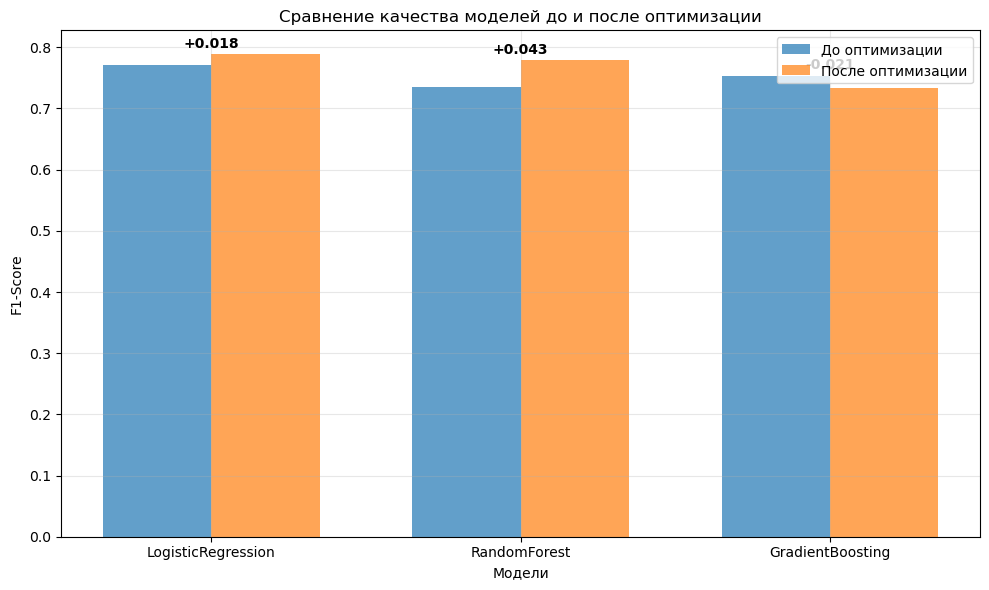

In [28]:
plt.figure(figsize=(10, 6))
x = np.arange(len(opt_df))
width = 0.35

plt.bar(x - width/2, opt_df['Base_F1'], width, label='До оптимизации', alpha=0.7)
plt.bar(x + width/2, opt_df['Optimized_F1'], width, label='После оптимизации', alpha=0.7)

plt.xlabel('Модели')
plt.ylabel('F1-Score')
plt.title('Сравнение качества моделей до и после оптимизации')
plt.xticks(x, opt_df['Model'])
plt.legend()
plt.grid(True, alpha=0.3)

for i, row in opt_df.iterrows():
    plt.text(i, max(row['Base_F1'], row['Optimized_F1']) + 0.01, 
             f"+{row['Improvement']:.3f}" if row['Improvement'] > 0 else f"{row['Improvement']:.3f}", 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Confusion Matrix для всех моделей

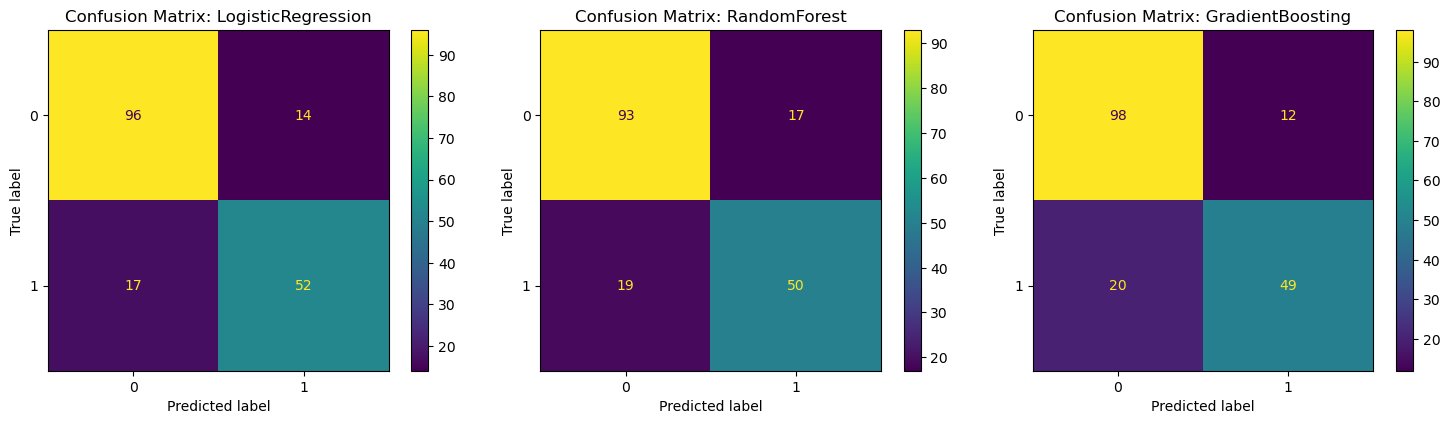

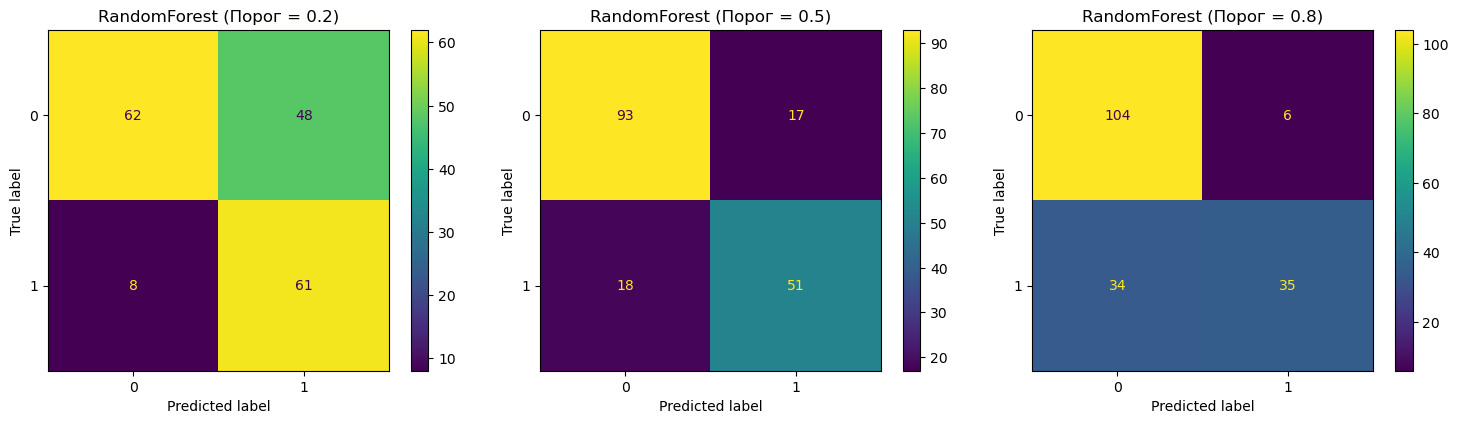

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix для всех моделей
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()

# Confusion Matrix для разных порогов (на примере RandomForest)
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)
y_proba = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
thresholds = [0.2, 0.5, 0.8]

for idx, thr in enumerate(thresholds):
    y_pred_thr = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx])
    axes[idx].set_title(f'RandomForest (Порог = {thr})')

plt.tight_layout()
plt.show()

### ROC-кривая для всех моделей

/home/cbf/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


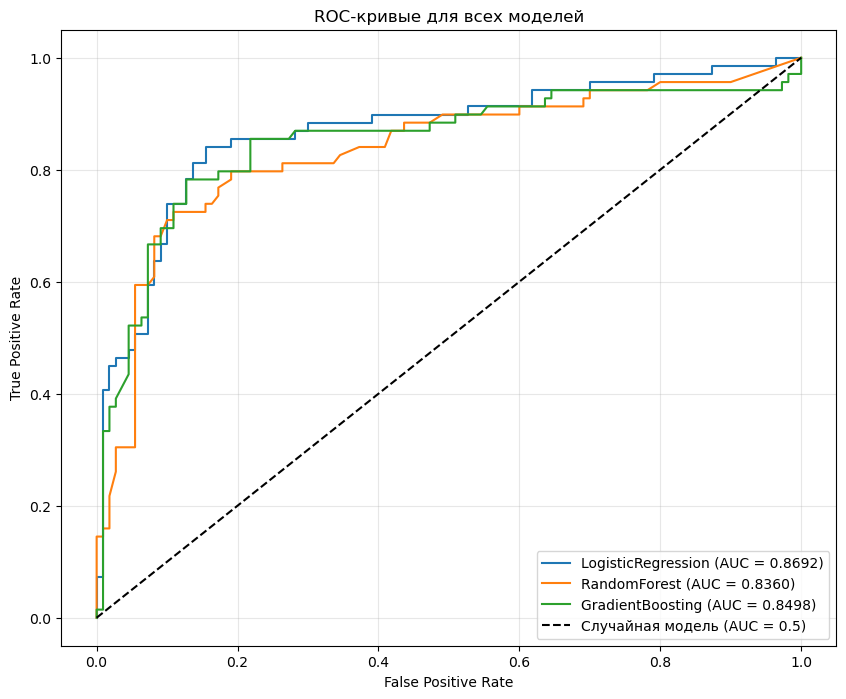

In [30]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для всех моделей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Вывод по лабораторной №3

Для LogisticRegression оптимизация дала небольшое улучшение F1-score с 0.7704 до 0.7883. Поскольку метрика выросла, а модель не склонна к сильному переобучению, рекомендуется использовать оптимизированную версию с найденными параметрами. \
RandomForest показал наибольший прирост качества — почти 4.3%. Это значительное улучшение, и оптимизированную модель стоит взять в эксплуатацию. \
GradientBoosting, несмотря на подбор параметров, показал худший результат F1-score после оптимизации. Вероятно, в процессе кросс-валидации подобрались параметры, которые хуже обобщают данные на нашем тестовом наборе. В данном случае целесообразно оставить базовую модель или исследовать проблему глубже.